## Module 3 Class activities
This notebook is a starting point for the exercises and activities that we'll do in class.

Before you attempt any of these activities, make sure to watch the video lectures for this module.

### Aggregation
Let's look at the spatial distribution of vaccine hesitancy, early in the pandemic.

The CDC has a dataset at the county level, [available via Socrata](https://data.cdc.gov/Vaccinations/Vaccine-Hesitancy-for-COVID-19-County-and-local-es/q9mh-h2tw).


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Import the vaccine hesitancy dataset into a dataframe. Call it <strong>hesitancy</strong>.
</div>

*Hint*: Use the same approach as for the Seattle permits (class 2) or the Los Angeles housing (lecture 5). Just use a different URL.

*Hint*: Add the `limit` keyword at the end of the URL to get more than 1000 rows. [See the example here](https://github.com/socrata/discuss/issues/145). There are 3,142 rows, according to the dataset's webpage, so you will be safe if you specify a limit of (say) 5000 rows.

In [17]:
# your code here
# hesitancy = 9999

import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup

url = 'https://data.cdc.gov/resource/q9mh-h2tw.json?$limit=5000' # copied and pasted from the webpage
r = requests.get(url)
hesitancy = pd.DataFrame(json.loads(r.text))

In [9]:
hesitancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   fips_code                      3142 non-null   object
 1   county_name                    3142 non-null   object
 2   state                          3142 non-null   object
 3   estimated_hesitant             3142 non-null   object
 4   estimated_hesitant_or_unsure   3142 non-null   object
 5   estimated_strongly_hesitant    3142 non-null   object
 6   social_vulnerability_index     3141 non-null   object
 7   svi_category                   3141 non-null   object
 8   ability_to_handle_a_covid      3142 non-null   object
 9   cvac_category                  3142 non-null   object
 10  percent_adults_fully           2864 non-null   object
 11  percent_hispanic               3142 non-null   object
 12  percent_non_hispanic_american  3142 non-null   object
 13  per

Before we do any joins, let's look at some state-level summary statistics.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a dataframe with the state-level means of estimated_hesitant and the vaccination rate.
</div>

*Hints*:
- It might make more sense to weight each county by population, but let's not worry about that here.
- The `percent_adults_fully` columm gives the vaccination rate (as of June 2021)
- Use `groupby`!
- Before you do any operations, you might need to convert the data type of the column. I recommend creating a new column, e.g. `df['newcol'] = df.oldcol.astype(float)`

In [ ]:
# your code here

In [18]:
hesitancy['estimated_hesitant_float'] = hesitancy.estimated_hesitant.astype(float)

In [20]:
hesitancy['percent_adults_fully_float'] = hesitancy.percent_adults_fully.astype(float)

In [23]:
hesitancy.groupby('state')[['estimated_hesitant_float','percent_adults_fully_float']].mean()
#正解版ではstatelevel = hesitancy.groupby~という形で、州ごとの平均をまとめたデータを別のデータセットとして設定している
#（自分はしていなかった。なので、その下でhesitancyをplotしたら州ごとではなくcountyごとのplotになった）

,estimated_hesitant_float,percent_adults_fully_float
state,,
ALABAMA,0.173507,0.320851
ALASKA,0.217386,0.582296
ARIZONA,0.159240,0.504733
ARKANSAS,0.212123,0.338800
CALIFORNIA,0.072274,0.506820
COLORADO,0.078220,0.330641
CONNECTICUT,0.056987,0.655875
DELAWARE,0.059433,0.518667
DISTRICT OF COLUMBIA,0.065500,0.546000


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a scatter plot of hesitancy vs vaccination rates.
</div>

<Axes: xlabel='estimated_hesitant_float', ylabel='percent_adults_fully_float'>

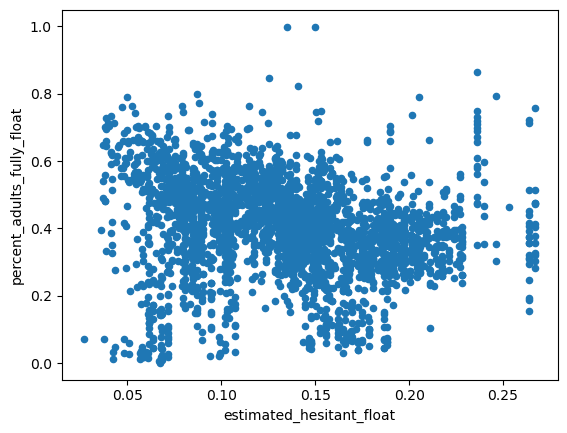

In [21]:
# your code here

hesitancy.plot('estimated_hesitant_float', 'percent_adults_fully_float', kind='scatter')
#正解版ではhesitancy.plotではなくstatelevel.plotでstatelevelのデータをplotしている

## Joining
Now let's do a join.
It looks like the county boundaries are in our original dataframe, but in a weird format. We could try and parse them. But instead, let's get the county boundaries and total population using the Census API and `pygris`. 

We'll just do one state, in order to reduce the sizes of the files for this exercise.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Get a geodataframe of the county boundaries and population totals for a state of your choice.
</div>

*Hints*: 
* Look at the [examples](https://www.census.gov/data/developers/guidance/api-user-guide.Example_API_Queries.html) provided by the Census Bureau
* You'll need to specify the state (e.g. "California") and the level (use "county"). So your API query will have some text like this: `for=county:*&in=state:06`
* A small state will download faster! You don't have to do California (FIPS 06)
* The population variable is B01001_001E
* To download the country boundaries, you'll need `pygris.counties` rather than `pygris.tracts` (which we used before)

In [13]:
import requests
import pandas as pd
import pygris

# add your code
r = requests.get('https://api.census.gov/data/2023/acs/acs5?get=B01001_001E&for=county:*&in=state:06')
censusdata = r.json()
df = pd.DataFrame(censusdata[1:], columns=censusdata[0])

In [14]:
df.head()

,B01001_001E,state,county
0,1651949,06,001
1,1695,06,003
2,41029,06,005
3,209470,06,007
4,45995,06,009


In [15]:
df["GEOID"] = df["state"] + df["county"]

In [16]:
df.head()

,B01001_001E,state,county,GEOID
0,1651949,06,001,06001
1,1695,06,003,06003
2,41029,06,005,06005
3,209470,06,007,06007
4,45995,06,009,06009


In [17]:
import geopandas as gpd
counties = gpd.read_file("/Users/Tomo/Desktop/UP213/Week3/tl_2024_us_county.zip")

In [18]:
counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477563042,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55525 41.82892, -96.55524 41.827..."
1,53,069,01513275,53069,0500000US53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980773,61564428,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
2,35,011,00933054,35011,0500000US35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016818941,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,None,A,2169269508,22850511,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645201,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


In [19]:
counties.set_index(['STATEFP','COUNTYFP'], inplace=True)
counties.index.names=['state','county']

In [20]:
CensusDf = counties[['geometry']].join(df.set_index(['state','county']))
#ここで、counties[['geometry']]のところにset_indexが無いのは、1つ上のboxでset_indexをすでにしているから

In [21]:
CensusDf.head()

geometry B01001_001E  \
state county                                                                  
31    039     POLYGON ((-96.55525 41.82892, -96.55524 41.827...         NaN   
53    069     POLYGON ((-123.72755 46.2645, -123.72756 46.26...         NaN   
35    011     POLYGON ((-104.89337 34.08894, -104.89337 34.0...         NaN   
31    109     POLYGON ((-96.68493 40.5233, -96.69219 40.5231...         NaN   
      129     POLYGON ((-98.2737 40.1184, -98.27374 40.1224,...         NaN   

             GEOID  
state county        
31    039      NaN  
53    069      NaN  
35    011      NaN  
31    109      NaN  
      129      NaN

You should now have `GEOID` as the index for your `censusDf`, as well as a geometry column.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Join the covid dataframe to your census dataframe.</div>

*Hints:*:
* Look at which column gives the county FIPS code in each dataframe.
* Do the data types match? Anything else you need to clean up before joining?
* It might be helpful to do a left join from the census dataframe. That means that you will automatically drop the data for counties in other states.

In [ ]:
# your code here

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create some county-level maps and other simple analyses.
</div>

The [geopandas documentation](https://geopandas.org/en/stable/docs/user_guide/mapping.html) has some useful tips.

Hint: make sure your column is numeric before you plot it!

In [ ]:
# your code here

<div class="alert alert-block alert-info">
<h3>What you should have learned</h3>
<ul>
  <li>Gain more practice with the APIs</li>
  <li>Understand basic data cleaning operations, such as converting strings to numeric fields.</li>
  <li>Understand how to compute group-level means and other summary statistics.</li>
    <li>Understand how to join tables on a common column.</li>
</ul>
</div>